In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/autompg-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'autompg-dataset' dataset.
Path to dataset files: /kaggle/input/autompg-dataset


    mpg  cylinders  displacement horsepower  weight  acceleration  model year  \
0  18.0          8         307.0        130    3504          12.0          70   
1  15.0          8         350.0        165    3693          11.5          70   
2  18.0          8         318.0        150    3436          11.0          70   
3  16.0          8         304.0        150    3433          12.0          70   
4  17.0          8         302.0        140    3449          10.5          70   

   origin                   car name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2 

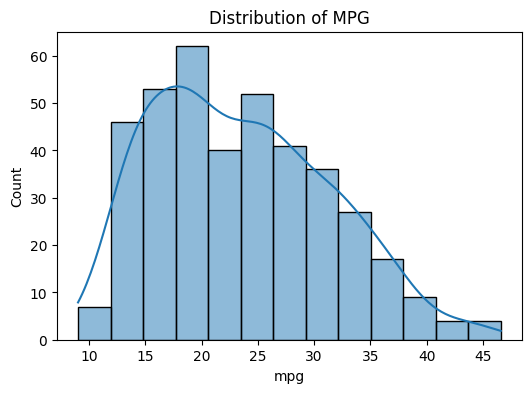

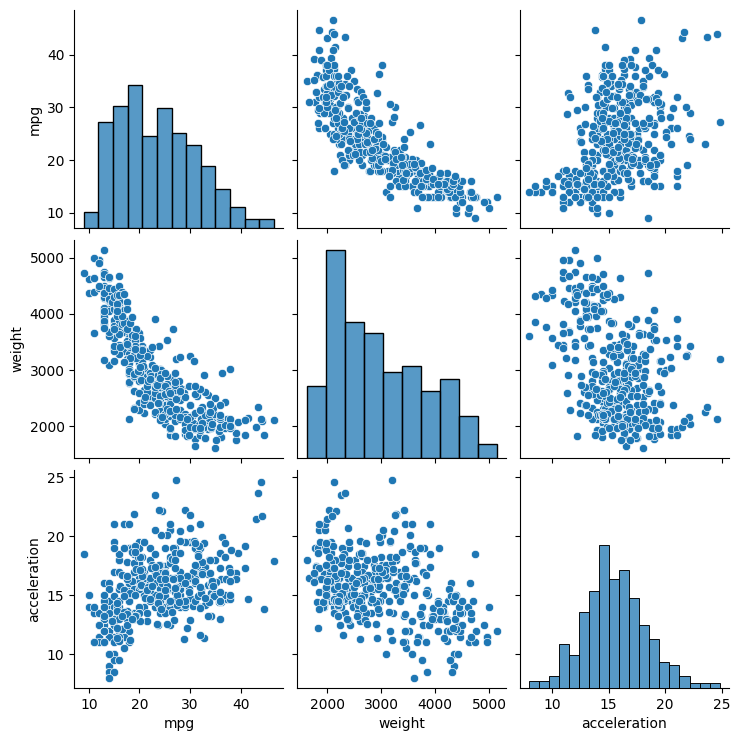

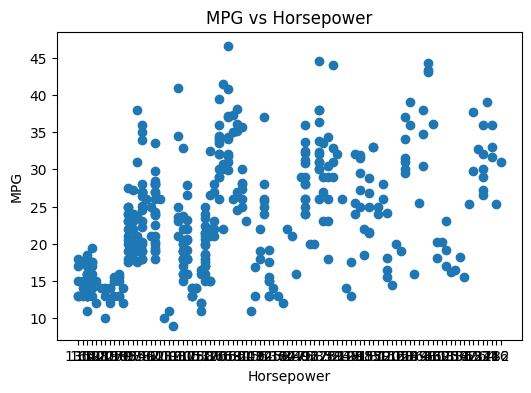

Horsepower Lower Bound: -1.5
Horsepower Upper Bound: 202.5

Shape before: (392, 9)
Shape after removing outliers: (382, 9)

Model BEFORE Removing Outliers
R2 Score: 0.5659681822256185
MSE: 22.153237123863413

Model AFTER Removing Outliers
R2 Score: 0.6994698685241629
MSE: 18.55780100636605


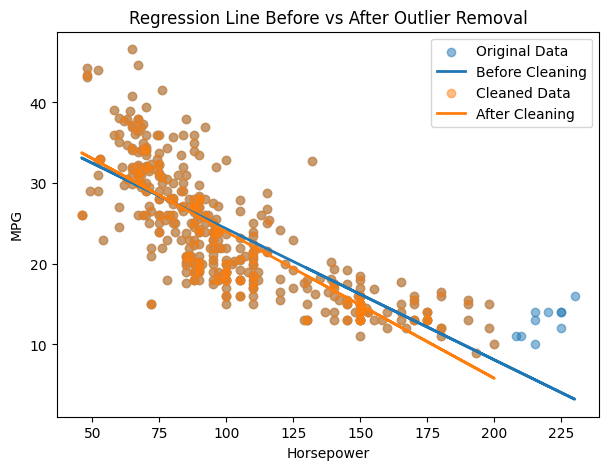

In [2]:
# -----------------------------------------
# 1. Load Libraries
# -----------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# -----------------------------------------
# 2. Load Dataset
# -----------------------------------------
df = pd.read_csv(f"{path}/auto-mpg.csv")

print(df.head())
print(df.info())
print(df.describe())

# Clean column names (remove weird characters)
df.columns = df.columns.str.strip()

# -----------------------------------------
# 3. Basic EDA
# -----------------------------------------

# Check missing values
print("\nMissing Values:")
print(df.isna().sum())

# Distribution of MPG
plt.figure(figsize=(6,4))
sns.histplot(df['mpg'], kde=True)
plt.title("Distribution of MPG")
plt.show()

# Pairplot (simple)
sns.pairplot(df[['mpg', 'horsepower', 'weight', 'acceleration']])
plt.show()

# Scatter plot MPG vs Horsepower
plt.figure(figsize=(6,4))
plt.scatter(df['horsepower'], df['mpg'])
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("MPG vs Horsepower")
plt.show()

# -----------------------------------------
# 4. Handle Missing Values
# -----------------------------------------
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df = df.dropna(subset=['horsepower'])

# -----------------------------------------
# 5. Detect Outliers using IQR
# -----------------------------------------
Q1 = df['horsepower'].quantile(0.25)
Q3 = df['horsepower'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Horsepower Lower Bound:", lower)
print("Horsepower Upper Bound:", upper)

df_outliers_removed = df[(df['horsepower'] >= lower) & (df['horsepower'] <= upper)]

print("\nShape before:", df.shape)
print("Shape after removing outliers:", df_outliers_removed.shape)

# -----------------------------------------
# 6. Build Regression Model (Before Outlier Removal)
# -----------------------------------------
X = df[['horsepower']]
y = df['mpg']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_before = LinearRegression()
model_before.fit(X_train, y_train)

pred_before = model_before.predict(X_test)

print("\nModel BEFORE Removing Outliers")
print("R2 Score:", r2_score(y_test, pred_before))
print("MSE:", mean_squared_error(y_test, pred_before))

# -----------------------------------------
# 7. Build Regression Model (After Outlier Removal)
# -----------------------------------------
X2 = df_outliers_removed[['horsepower']]
y2 = df_outliers_removed['mpg']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

model_after = LinearRegression()
model_after.fit(X2_train, y2_train)

pred_after = model_after.predict(X2_test)

print("\nModel AFTER Removing Outliers")
print("R2 Score:", r2_score(y2_test, pred_after))
print("MSE:", mean_squared_error(y2_test, pred_after))

# -----------------------------------------
# 8. Plot Regression Lines
# -----------------------------------------
plt.figure(figsize=(7,5))
plt.scatter(df['horsepower'], df['mpg'], label="Original Data", alpha=0.5)
plt.plot(df['horsepower'], model_before.predict(X), label="Before Cleaning", linewidth=2)

plt.scatter(df_outliers_removed['horsepower'], df_outliers_removed['mpg'],
            label="Cleaned Data", alpha=0.5)
plt.plot(df_outliers_removed['horsepower'],
         model_after.predict(X2), label="After Cleaning", linewidth=2)

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.legend()
plt.title("Regression Line Before vs After Outlier Removal")
plt.show()
